# Neural Network Replication: Gu, Kelly & Xiu (2020)
## "Empirical Asset Pricing via Machine Learning" — Review of Financial Studies

This notebook replicates the **five neural network architectures (NN1–NN5)** from GKX (2020).

### Paper Specifications
| Architecture | Hidden Layers | Neurons per Layer |
|---|---|---|
| NN1 | 1 | [32] |
| NN2 | 2 | [32, 16] |
| NN3 | 3 | [32, 16, 8] |
| NN4 | 4 | [32, 16, 8, 4] |
| NN5 | 5 | [32, 16, 8, 4, 2] |

**Training details:**
- Activation: ReLU
- Batch Normalization after each hidden layer
- Optimizer: Adam (default parameters)
- L1 penalty on weights: $\lambda_1 \in \{10^{-5}, 10^{-3}\}$
- Learning rate: $\text{LR} \in \{0.001, 0.01\}$
- Batch size: 10,000
- Max epochs: 100
- Early stopping with patience = 5 (monitored on validation MSE)
- Ensemble: average predictions from 10 networks with different random seeds
- Expanding-window scheme: retrain annually, training window grows each year

**Evaluation:**
- $R^2_{OOS} = 1 - \frac{\sum_{(i,t)\in\mathcal{T}_3}(r_{i,t+1} - \hat{r}_{i,t+1})^2}{\sum_{(i,t)\in\mathcal{T}_3} r_{i,t+1}^2}$
  (denominator is **not** demeaned — benchmark is a forecast of zero)

---
## Step 0: Install Dependencies & Imports

In [1]:
from pathlib import Path
from copy import deepcopy
import warnings
import time
import gc

try:
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
except ImportError as exc:
    raise ImportError(
        "Missing core packages. Select the `.venv` kernel and install them with:\n"
        "%pip install pandas numpy pyarrow tqdm openpyxl"
    ) from exc

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook requires PyTorch. Select the `.venv` kernel and install it with:\n"
        "%pip install torch"
    ) from exc

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "This notebook requires matplotlib for plots. Install it with:\n"
        "%pip install matplotlib"
    ) from exc

try:
    from scipy import stats
except ImportError as exc:
    raise ImportError(
        "This notebook requires scipy for the Diebold-Mariano test. Install it with:\n"
        "%pip install scipy"
    ) from exc

warnings.filterwarnings("ignore")

HAS_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_built()
MPS_AVAILABLE = HAS_MPS and torch.backends.mps.is_available()

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if MPS_AVAILABLE
                      else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {MPS_AVAILABLE}")

DATA_DIR = Path("data")

# ====================================================
# SMOKE TEST MODE
# Set to True for a quick sanity check (~minutes instead
# of hours). Reduces architectures, HP grid, ensemble
# size, epochs, and number of test years.
# Set to False for the full replication.
# ====================================================
SMOKE_TEST = True

if SMOKE_TEST:
    print("\n** SMOKE TEST MODE — reduced settings for quick validation **")

Using device: mps
PyTorch version: 2.11.0
MPS available: True

** SMOKE TEST MODE — reduced settings for quick validation **


---
## Step 1: Load the Trimmed GKX Panel

In [2]:
# ====================================================
# Load the trimmed panel (94 chars + 3 macro interaction
# blocks + industry dummies)
# ====================================================

panel = pd.read_parquet(DATA_DIR / "gkx2020_panel_trimmed.parquet")

# Convert date back to monthly Period
panel["date"] = pd.to_datetime(panel["date"]).dt.to_period("M")

print(f"Panel shape: {panel.shape}")
print(f"Date range: {panel['date'].min()} to {panel['date'].max()}")
print(f"Unique stocks: {panel['permno'].nunique():,}")
print(f"Memory usage: {panel.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Panel shape: (3305648, 283)
Date range: 1957-03 to 2021-12
Unique stocks: 25,770
Memory usage: 2.72 GB


---
## Step 2: Identify Feature Columns & Target

In [3]:
# ====================================================
# Separate ID columns, target, and features
# ====================================================

# ID / metadata columns (not used as features)
id_cols = ["permno", "date", "ret_excess", "me", "exchcd"]

# Target variable
target_col = "ret_excess"

# All remaining columns are features
feature_cols = [c for c in panel.columns if c not in id_cols]

# Breakdown of feature types
char_cols = [c for c in feature_cols if not c.startswith("ind_") and "_x_" not in c]
interaction_cols = [c for c in feature_cols if "_x_" in c]
industry_cols = [c for c in feature_cols if c.startswith("ind_")]

print(f"Total features: {len(feature_cols)}")
print(f"  - Firm characteristics: {len(char_cols)}")
print(f"  - Char × macro interactions: {len(interaction_cols)}")
print(f"  - Industry dummies: {len(industry_cols)}")
print(f"Target: {target_col}")

Total features: 278
  - Firm characteristics: 94
  - Char × macro interactions: 94
  - Industry dummies: 90
Target: ret_excess


---
## Step 3: Define Sample Splits (Expanding Window)

Following GKX (2020) and their Internet Appendix D:

- **Training:** starts at 1957, expands by one year each refit
- **Validation:** 12-year rolling window immediately after training
- **Test:** the single year right after the validation window

The model is refit **once per year**. Each refit produces OOS predictions for
the subsequent 12 months. The overall OOS test period is **1987–2021**.

In [4]:
# ====================================================
# Build the list of expanding-window splits
# ====================================================

TRAIN_START_YEAR = 1957
VALID_YEARS = 12          # fixed-size validation window
TEST_START_YEAR = 1987
TEST_END_YEAR = panel["date"].dt.year.max()  # last year in data

splits = []
for test_year in range(TEST_START_YEAR, TEST_END_YEAR + 1):
    # Training: TRAIN_START_YEAR up to (test_year - VALID_YEARS - 1)
    train_end_year = test_year - VALID_YEARS - 1
    valid_start_year = train_end_year + 1
    valid_end_year = test_year - 1

    splits.append({
        "train": (TRAIN_START_YEAR, train_end_year),
        "valid": (valid_start_year, valid_end_year),
        "test":  (test_year, test_year),
    })

# In smoke-test mode, keep only the last 2 annual refits
if SMOKE_TEST:
    splits = splits[-2:]
    print(f"SMOKE TEST: trimmed to {len(splits)} splits")

print(f"Number of annual refits: {len(splits)}")
print(f"First split: train {splits[0]['train']}, valid {splits[0]['valid']}, test {splits[0]['test']}")
print(f"Last split:  train {splits[-1]['train']}, valid {splits[-1]['valid']}, test {splits[-1]['test']}")

SMOKE TEST: trimmed to 2 splits
Number of annual refits: 2
First split: train (1957, 2007), valid (2008, 2019), test (2020, 2020)
Last split:  train (1957, 2008), valid (2009, 2020), test (2021, 2021)


---
## Step 4: Define the GKX Neural Network Architecture

Each network follows the structure from Section 1.7 and Appendix B.3 of the paper:

```
Input → [Linear → BatchNorm → ReLU] × L → Linear → Output (1 neuron)
```

Regularization:
- **L1 penalty** on all weight matrices (not biases)
- **Early stopping** on validation MSE (patience = 5)
- **Batch normalization** after each hidden layer
- **Ensemble** of 10 independently initialized networks

In [5]:
# ====================================================
# GKX Neural Network model (PyTorch)
# ====================================================

class GKXNet(nn.Module):
    """
    Feed-forward neural network replicating GKX (2020).

    Architecture: Input → [Linear → BN → ReLU] × L → Linear(1)
    Follows the geometric pyramid rule for layer widths.
    """

    def __init__(self, input_dim: int, hidden_sizes: list[int]):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            prev_dim = h

        # Output layer: single linear neuron (no activation)
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


# ====================================================
# GKX architecture definitions (Table from paper p.2244)
# ====================================================

NN_ARCHITECTURES = {
    "NN1": [32],
    "NN2": [32, 16],
    "NN3": [32, 16, 8],
    "NN4": [32, 16, 8, 4],
    "NN5": [32, 16, 8, 4, 2],
}

print("GKX Neural Network architectures:")
for name, layers in NN_ARCHITECTURES.items():
    print(f"  {name}: {layers}")

GKX Neural Network architectures:
  NN1: [32]
  NN2: [32, 16]
  NN3: [32, 16, 8]
  NN4: [32, 16, 8, 4]
  NN5: [32, 16, 8, 4, 2]


---
## Step 5: Training Utilities

Implements:
- **L1 penalty** computation on weight parameters
- **Early stopping** with patience (Algorithm 6 from the Internet Appendix)
- **Single-model training loop** with Adam (Algorithm 5 from the Internet Appendix)

In [6]:
# ====================================================
# L1 penalty: sum of absolute values of weight params
# (biases excluded, following standard practice)
# ====================================================

def l1_penalty(model: nn.Module) -> torch.Tensor:
    """Compute L1 norm of all weight (non-bias) parameters."""
    l1 = torch.tensor(0.0, device=DEVICE)
    for name, param in model.named_parameters():
        if "weight" in name and "bn" not in name.lower():
            l1 = l1 + param.abs().sum()
    return l1


# ====================================================
# Train a single neural network with early stopping
# ====================================================

def train_single_nn(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_valid: torch.Tensor,
    y_valid: torch.Tensor,
    lr: float = 0.001,
    l1_lambda: float = 1e-5,
    batch_size: int = 10_000,
    max_epochs: int = 100,
    patience: int = 5,
) -> nn.Module:
    """
    Train one GKX neural network.

    Uses Adam optimizer, MSE loss + L1 penalty, and early
    stopping monitored on validation MSE.

    Returns the model with the best validation loss.
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # DataLoader for mini-batch SGD
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=False
    )

    # Early stopping state
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # --- Training phase ---
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch) + l1_lambda * l1_penalty(model)
            loss.backward()
            optimizer.step()

        # --- Validation phase ---
        model.eval()
        with torch.no_grad():
            val_preds = model(X_valid)
            val_loss = criterion(val_preds, y_valid).item()

        # --- Early stopping check (Algorithm 6) ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    # Restore best model
    model.load_state_dict(best_state)
    return model

---
## Step 6: Hyperparameter Tuning via Validation

Following Table A.5 of the Internet Appendix, for each architecture we search over:
- $\lambda_1 \in \{10^{-5}, 10^{-3}\}$ (L1 penalty strength)
- $\text{LR} \in \{0.001, 0.01\}$ (learning rate)

The best combination is selected by **validation MSE** for each annual refit.

In [7]:
# ====================================================
# Hyperparameter grid (from Table A.5)
# ====================================================

if SMOKE_TEST:
    # Minimal grid for smoke test: 1 HP combo, tiny ensemble, few epochs
    HYPERPARAM_GRID = [{"lr": 0.001, "l1_lambda": 1e-5}]
    BATCH_SIZE = 10_000
    MAX_EPOCHS = 5
    PATIENCE = 2
    N_ENSEMBLE = 2
else:
    # Full replication settings
    HYPERPARAM_GRID = [
        {"lr": 0.001, "l1_lambda": 1e-5},
        {"lr": 0.001, "l1_lambda": 1e-3},
        {"lr": 0.01,  "l1_lambda": 1e-5},
        {"lr": 0.01,  "l1_lambda": 1e-3},
    ]
    BATCH_SIZE = 10_000
    MAX_EPOCHS = 100
    PATIENCE = 5
    N_ENSEMBLE = 10

print(f"Hyperparameter combinations: {len(HYPERPARAM_GRID)}")
print(f"Ensemble size: {N_ENSEMBLE}")
print(f"Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}")
print(f"Total models per architecture per refit: {len(HYPERPARAM_GRID)} HP combos × {N_ENSEMBLE} seeds")

Hyperparameter combinations: 1
Ensemble size: 2
Max epochs: 5, Patience: 2
Total models per architecture per refit: 1 HP combos × 2 seeds


---
## Step 7: Data Preparation Helpers

Utility functions to:
1. Extract train/valid/test splits for a given year window
2. Convert pandas DataFrames to PyTorch tensors on the right device

In [8]:
# ====================================================
# Helper: extract data for one expanding-window split
# ====================================================

def get_split_data(panel: pd.DataFrame, split: dict):
    """
    Given a split dict with (start_year, end_year) tuples for
    train/valid/test, return X and y tensors for each subset.
    """
    years = panel["date"].dt.year

    # Boolean masks
    train_mask = (years >= split["train"][0]) & (years <= split["train"][1])
    valid_mask = (years >= split["valid"][0]) & (years <= split["valid"][1])
    test_mask  = (years >= split["test"][0])  & (years <= split["test"][1])

    def to_tensors(mask):
        sub = panel.loc[mask]
        X = torch.tensor(sub[feature_cols].values, dtype=torch.float32, device=DEVICE)
        y = torch.tensor(sub[target_col].values, dtype=torch.float32, device=DEVICE)
        return X, y

    X_train, y_train = to_tensors(train_mask)
    X_valid, y_valid = to_tensors(valid_mask)
    X_test, y_test   = to_tensors(test_mask)

    return X_train, y_train, X_valid, y_valid, X_test, y_test

---
## Step 8: Full Training Pipeline

For **each architecture** (NN1–NN5) and **each annual refit**:

1. Select the best hyperparameters via validation MSE  
   (train one model per HP combo, pick the combo with lowest val loss)
2. Train an **ensemble of 10 models** with the best HPs (different seeds)
3. Generate OOS predictions by **averaging** ensemble predictions
4. Store predictions and actuals for the test year

In [9]:
# ====================================================
# Core training pipeline for one architecture
# ====================================================

def train_architecture(
    panel: pd.DataFrame,
    arch_name: str,
    hidden_sizes: list[int],
    splits: list[dict],
) -> dict:
    """
    Train a GKX neural network architecture across all annual refits.

    For each refit year:
      1. Tune hyperparameters on validation set
      2. Train an ensemble of N_ENSEMBLE models with best HPs
      3. Average ensemble predictions on the test year

    Returns a dict with lists of predictions and actuals.
    """
    all_preds = []
    all_actuals = []
    all_test_years = []
    input_dim = len(feature_cols)

    print(f"\n{'='*60}")
    print(f"Training {arch_name}: hidden layers = {hidden_sizes}")
    print(f"{'='*60}")

    for split_idx, split in enumerate(splits):
        test_year = split["test"][0]
        t0 = time.time()

        # --- Load data for this split ---
        X_train, y_train, X_valid, y_valid, X_test, y_test = get_split_data(panel, split)

        # Skip if test set is empty (can happen at boundaries)
        if X_test.shape[0] == 0:
            print(f"  Year {test_year}: no test data, skipping.")
            continue

        # --- Step 1: Hyperparameter tuning ---
        best_hp = None
        best_val_loss = float("inf")

        for hp in HYPERPARAM_GRID:
            # Train a single model with this HP combo (seed=0 for tuning)
            torch.manual_seed(0)
            model = GKXNet(input_dim, hidden_sizes)
            model = train_single_nn(
                model, X_train, y_train, X_valid, y_valid,
                lr=hp["lr"], l1_lambda=hp["l1_lambda"],
                batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE,
            )

            # Evaluate on validation set
            model.eval()
            with torch.no_grad():
                val_preds = model(X_valid)
                val_loss = nn.MSELoss()(val_preds, y_valid).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_hp = hp

            del model

        # --- Step 2: Train ensemble with best HPs ---
        ensemble_preds = torch.zeros(X_test.shape[0], device=DEVICE)

        for seed in range(N_ENSEMBLE):
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = GKXNet(input_dim, hidden_sizes)
            model = train_single_nn(
                model, X_train, y_train, X_valid, y_valid,
                lr=best_hp["lr"], l1_lambda=best_hp["l1_lambda"],
                batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE,
            )

            # Predict on test set
            model.eval()
            with torch.no_grad():
                ensemble_preds += model(X_test)

            del model

        # Average ensemble predictions
        ensemble_preds /= N_ENSEMBLE

        # Store results
        all_preds.append(ensemble_preds.cpu().numpy())
        all_actuals.append(y_test.cpu().numpy())
        all_test_years.extend([test_year] * X_test.shape[0])

        elapsed = time.time() - t0
        print(
            f"  Year {test_year}: "
            f"train={X_train.shape[0]:>8,}, "
            f"valid={X_valid.shape[0]:>8,}, "
            f"test={X_test.shape[0]:>7,} | "
            f"best HP: lr={best_hp['lr']}, λ1={best_hp['l1_lambda']} | "
            f"{elapsed:.0f}s"
        )

        # Free GPU memory
        del X_train, y_train, X_valid, y_valid, X_test, y_test, ensemble_preds
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    return {
        "preds": np.concatenate(all_preds),
        "actuals": np.concatenate(all_actuals),
        "test_years": np.array(all_test_years),
    }

---
## Step 9: Run Training for All Architectures (NN1–NN5)

**Note:** This is computationally intensive. Each architecture requires
`(4 HP combos + 10 ensemble) × ~35 annual refits` model trainings.
Expect several hours on CPU, much faster on GPU.

You can run a subset of architectures first by modifying `archs_to_run`.

In [10]:
# ====================================================
# Select which architectures to train
# (modify this list to run a subset, e.g. ["NN1", "NN3"])
# ====================================================

if SMOKE_TEST:
    archs_to_run = ["NN1"]  # single shallow net for quick check
else:
    archs_to_run = ["NN1", "NN2", "NN3", "NN4", "NN5"]

# Store results for each architecture
results = {}

total_start = time.time()

for arch_name in archs_to_run:
    hidden_sizes = NN_ARCHITECTURES[arch_name]
    results[arch_name] = train_architecture(panel, arch_name, hidden_sizes, splits)

total_elapsed = time.time() - total_start
print(f"\nTotal training time: {total_elapsed / 60:.1f} minutes")


Training NN1: hidden layers = [32]
  Year 2020: train=2,666,568, valid= 547,629, test= 43,027 | best HP: lr=0.001, λ1=1e-05 | 459s
  Year 2021: train=2,720,142, valid= 537,082, test= 48,424 | best HP: lr=0.001, λ1=1e-05 | 500s

Total training time: 16.0 minutes


---
## Step 10: Compute Out-of-Sample $R^2_{OOS}$

From Equation (19) of the paper:

$$R^2_{OOS} = 1 - \frac{\sum_{(i,t)\in\mathcal{T}_3}(r_{i,t+1} - \hat{r}_{i,t+1})^2}{\sum_{(i,t)\in\mathcal{T}_3} r_{i,t+1}^2}$$

The denominator uses **raw squared returns** (not demeaned), so the
benchmark is a naive forecast of zero.

In [11]:
# ====================================================
# R²_OOS computation (Equation 19)
# ====================================================

def r2_oos(actuals: np.ndarray, preds: np.ndarray) -> float:
    """
    GKX out-of-sample R² (Eq. 19).
    Benchmark = forecast of zero (denominator is sum of r²).
    """
    ss_res = np.sum((actuals - preds) ** 2)
    ss_tot = np.sum(actuals ** 2)
    return 1.0 - ss_res / ss_tot


# ====================================================
# Overall R²_OOS for each architecture
# ====================================================

print("\n" + "=" * 50)
print("Out-of-Sample R² (pooled across all test years)")
print("=" * 50)

r2_results = {}
for arch_name in archs_to_run:
    res = results[arch_name]
    r2 = r2_oos(res["actuals"], res["preds"])
    r2_results[arch_name] = r2
    print(f"  {arch_name}: R²_OOS = {r2 * 100:.4f}%")

print("\nReference from paper (Table 6):")
print("  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%")


Out-of-Sample R² (pooled across all test years)
  NN1: R²_OOS = 0.4183%

Reference from paper (Table 6):
  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%


---
## Step 11: Annual $R^2_{OOS}$ Breakdown

Examine how predictive performance varies year by year.

In [12]:
# ====================================================
# Year-by-year R²_OOS
# ====================================================

annual_r2 = {}

for arch_name in archs_to_run:
    res = results[arch_name]
    years = np.unique(res["test_years"])
    yearly_r2 = []
    for yr in years:
        mask = res["test_years"] == yr
        r2 = r2_oos(res["actuals"][mask], res["preds"][mask])
        yearly_r2.append(r2)
    annual_r2[arch_name] = pd.Series(yearly_r2, index=years)

annual_r2_df = pd.DataFrame(annual_r2) * 100  # convert to %
print("Annual R²_OOS (%) — first and last 5 years:")
print(annual_r2_df.head())
print("...")
print(annual_r2_df.tail())

Annual R²_OOS (%) — first and last 5 years:
           NN1
2020  0.466537
2021  0.354570
...
           NN1
2020  0.466537
2021  0.354570


---
## Step 12: Plot Annual $R^2_{OOS}$ Over Time

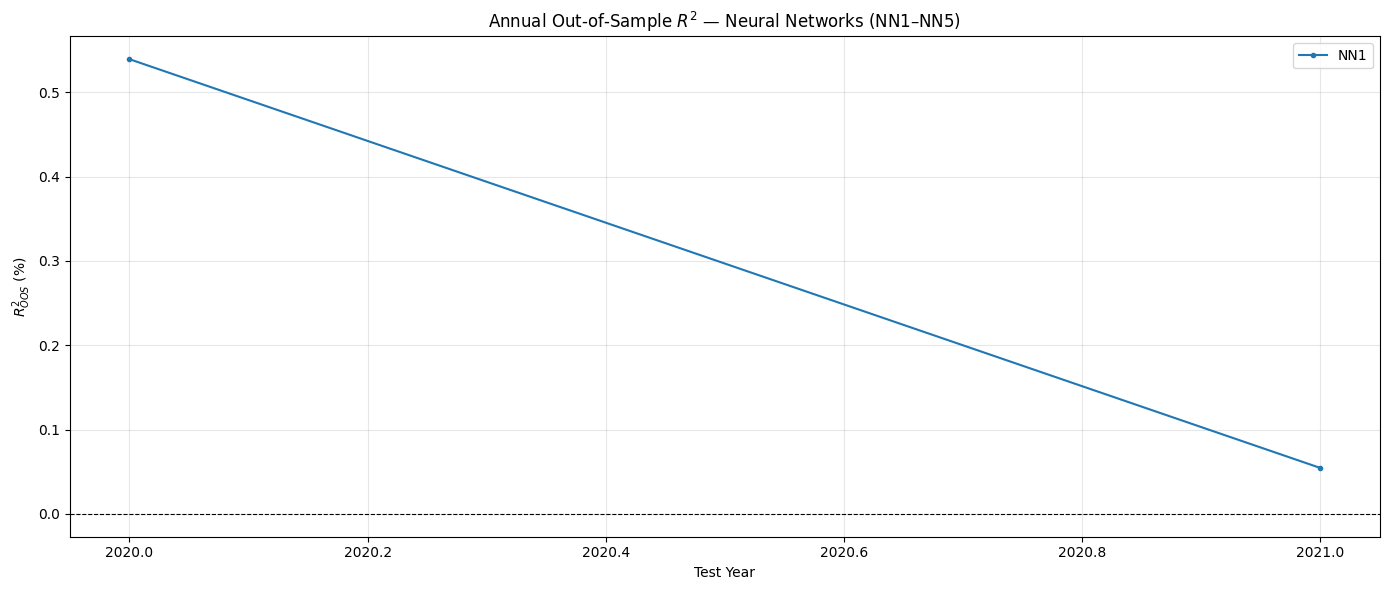

In [13]:
# ====================================================
# Time series plot of annual R²_OOS
# ====================================================

fig, ax = plt.subplots(figsize=(14, 6))

for arch_name in archs_to_run:
    ax.plot(annual_r2_df.index, annual_r2_df[arch_name], marker="o",
            markersize=3, label=arch_name)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Test Year")
ax.set_ylabel("$R^2_{OOS}$ (%)")
ax.set_title("Annual Out-of-Sample $R^2$ — Neural Networks (NN1–NN5)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 13: Diebold-Mariano Test for Pairwise Model Comparison

From Equation (20) of the paper, adapted for panel data:

$$d_{12,t+1} = \frac{1}{n_{3,t+1}} \sum_{i=1}^{n_{3,t+1}} \left[ (\hat{e}^{(1)}_{i,t+1})^2 - (\hat{e}^{(2)}_{i,t+1})^2 \right]$$

The DM statistic is $DM_{12} = \bar{d}_{12} / \hat{\sigma}_{\bar{d}_{12}}$ using Newey-West standard errors.

In [14]:
# ====================================================
# Diebold-Mariano test (GKX panel adaptation, Eq. 20)
# ====================================================

def newey_west_se(x: np.ndarray, max_lag: int = None) -> float:
    """Newey-West HAC standard error for a 1-D time series."""
    T = len(x)
    if max_lag is None:
        max_lag = int(np.floor(4 * (T / 100) ** (2 / 9)))
    x_dm = x - x.mean()
    gamma_0 = np.dot(x_dm, x_dm) / T
    gamma_sum = 0.0
    for j in range(1, max_lag + 1):
        w = 1 - j / (max_lag + 1)
        gamma_j = np.dot(x_dm[j:], x_dm[:-j]) / T
        gamma_sum += 2 * w * gamma_j
    var = (gamma_0 + gamma_sum) / T
    return np.sqrt(max(var, 1e-20))


def dm_test_panel(
    actuals: np.ndarray,
    preds1: np.ndarray,
    preds2: np.ndarray,
    test_years: np.ndarray,
) -> tuple[float, float]:
    """
    Panel Diebold-Mariano test (GKX Eq. 20).

    Tests H0: Model 1 and Model 2 have equal predictive accuracy.
    Positive DM stat means Model 2 is better (lower MSE).

    Returns (DM statistic, two-sided p-value).
    """
    e1_sq = (actuals - preds1) ** 2
    e2_sq = (actuals - preds2) ** 2

    # Cross-sectional average of squared error differences per year
    unique_years = np.sort(np.unique(test_years))
    d_t = []
    for yr in unique_years:
        mask = test_years == yr
        d_t.append(np.mean(e1_sq[mask] - e2_sq[mask]))
    d_t = np.array(d_t)

    d_bar = d_t.mean()
    se = newey_west_se(d_t)
    dm_stat = d_bar / se if se > 0 else 0.0
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return dm_stat, p_value


# ====================================================
# Pairwise DM tests across all NN architectures
# ====================================================

if len(archs_to_run) > 1:
    print("\nDiebold-Mariano test (positive stat → column model is better):")
    print(f"{'':>6}", end="")
    for name in archs_to_run:
        print(f"{name:>10}", end="")
    print()

    for i, name_i in enumerate(archs_to_run):
        print(f"{name_i:>6}", end="")
        for j, name_j in enumerate(archs_to_run):
            if i == j:
                print(f"{'—':>10}", end="")
            else:
                dm, pv = dm_test_panel(
                    results[name_i]["actuals"],
                    results[name_i]["preds"],
                    results[name_j]["preds"],
                    results[name_i]["test_years"],
                )
                stars = "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.1 else ""
                print(f"{dm:>7.2f}{stars:<3}", end="")
        print()

---
## Step 14: Variable Importance (SSD)

From Section 1.9 and footnote 27 of the paper, **SSD** (Sum of Squared Derivatives)
measures how sensitive the model is to each input variable:

$$SSD_j = \sum_{i,t \in \mathcal{T}_1} \left( \frac{\partial g(z;\theta)}{\partial z_j} \bigg|_{z=z_{i,t}} \right)^2$$

We compute this using the **last trained ensemble** (final refit year) on the
training data, then report the top-20 most important characteristics.

In [15]:
# ====================================================
# Variable Importance via SSD (using the final refit)
# ====================================================

def compute_ssd(model: nn.Module, X: torch.Tensor, feature_names: list[str]) -> pd.Series:
    """
    Compute Sum of Squared Derivatives (SSD) for each input feature.
    Uses autograd to get ∂g/∂z_j for all observations.
    """
    model.eval()
    X_grad = X.clone().detach().requires_grad_(True)
    preds = model(X_grad)
    preds.sum().backward()
    grads = X_grad.grad.detach()  # (N, P)

    # SSD = sum of squared partial derivatives per feature
    ssd = (grads ** 2).sum(dim=0).cpu().numpy()
    return pd.Series(ssd, index=feature_names)


def compute_ensemble_ssd(
    panel: pd.DataFrame,
    arch_name: str,
    hidden_sizes: list[int],
    split: dict,
    best_hp: dict = None,
    n_seeds: int = 3,     # fewer seeds for speed
    max_obs: int = 50_000, # subsample for memory
) -> pd.Series:
    """
    Retrain a small ensemble on the final split and compute
    average SSD across ensemble members.
    """
    input_dim = len(feature_cols)

    X_train, y_train, X_valid, y_valid, _, _ = get_split_data(panel, split)

    # Use defaults if no best_hp provided
    if best_hp is None:
        best_hp = {"lr": 0.001, "l1_lambda": 1e-5}

    # Subsample training data for SSD computation
    if X_train.shape[0] > max_obs:
        idx = torch.randperm(X_train.shape[0])[:max_obs]
        X_ssd = X_train[idx]
    else:
        X_ssd = X_train

    ssd_total = pd.Series(0.0, index=feature_cols)

    for seed in range(n_seeds):
        torch.manual_seed(seed + 100)
        model = GKXNet(input_dim, hidden_sizes)
        model = train_single_nn(
            model, X_train, y_train, X_valid, y_valid,
            lr=best_hp["lr"], l1_lambda=best_hp["l1_lambda"],
            batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE,
        )
        ssd_total += compute_ssd(model, X_ssd, feature_cols)
        del model

    ssd_avg = ssd_total / n_seeds

    # Normalize to percentages
    ssd_pct = (ssd_avg / ssd_avg.sum()) * 100

    del X_train, y_train, X_valid, y_valid, X_ssd
    gc.collect()

    return ssd_pct.sort_values(ascending=False)


# --- Compute SSD for NN3 (the paper's main architecture for VI) ---
print("Computing variable importance (SSD) for NN3 on the final split...")
print("(This retrains a small ensemble — may take a few minutes.)\n")

ssd_nn3 = compute_ensemble_ssd(
    panel, "NN3", NN_ARCHITECTURES["NN3"], splits[-1],
)

print("Top 20 most important features (NN3, SSD %):\n")
print(ssd_nn3.head(20).to_string())

Computing variable importance (SSD) for NN3 on the final split...
(This retrains a small ensemble — may take a few minutes.)

Top 20 most important features (NN3, SSD %):

mvel1               4.368864
dolvol              2.941351
mom1m               2.471718
std_turn            2.172955
ind_60              1.932879
invest              1.789962
lev                 1.693955
idiovol             1.547218
turn                1.501150
gma                 1.456338
ill                 1.451396
retvol              1.432746
egr                 1.354672
mvel1_x_bm_macro    1.332340
beta_x_bm_macro     1.209243
ind_49              1.124760
mom1m_x_bm_macro    1.122509
egr_x_bm_macro      1.118829
agr_x_bm_macro      1.110923
baspread            1.106165


---
## Step 15: Plot Variable Importance

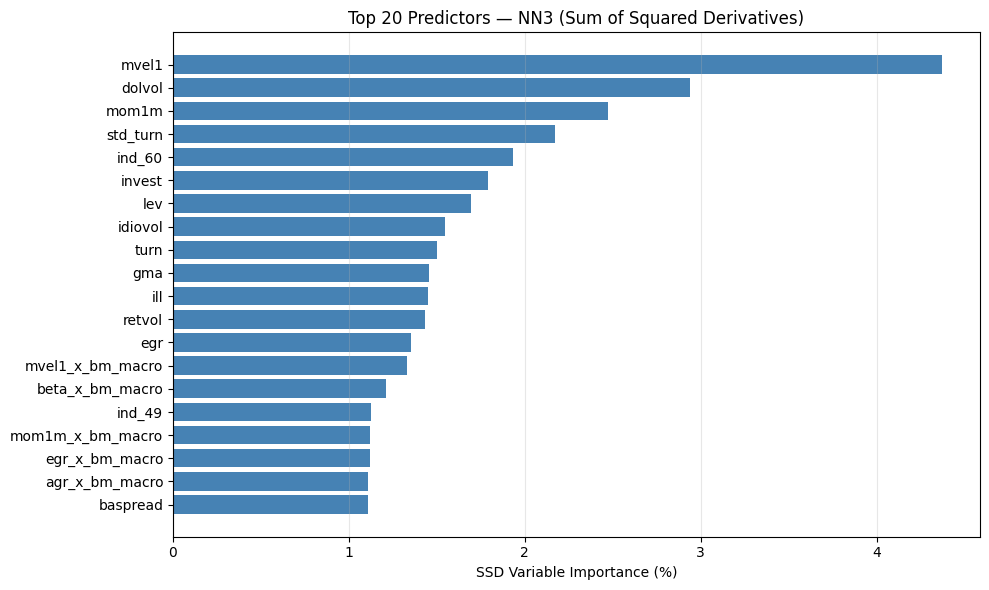

In [16]:
# ====================================================
# Bar chart of top-20 SSD variable importance
# ====================================================

top_n = 20
top_ssd = ssd_nn3.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n), top_ssd.values[::-1], color="steelblue")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_ssd.index[::-1])
ax.set_xlabel("SSD Variable Importance (%)")
ax.set_title("Top 20 Predictors — NN3 (Sum of Squared Derivatives)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 16: Summary Results Table

In [17]:
# ====================================================
# Summary comparison table
# ====================================================

summary_rows = []
for arch_name in archs_to_run:
    res = results[arch_name]
    r2 = r2_oos(res["actuals"], res["preds"]) * 100
    n_obs = len(res["actuals"])
    mean_pred = res["preds"].mean()
    std_pred = res["preds"].std()
    summary_rows.append({
        "Architecture": arch_name,
        "Hidden Layers": str(NN_ARCHITECTURES[arch_name]),
        "R²_OOS (%)": f"{r2:.4f}",
        "N Test Obs": f"{n_obs:,}",
        "Mean Pred": f"{mean_pred:.6f}",
        "Std Pred": f"{std_pred:.6f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 70)
print("NEURAL NETWORK REPLICATION — SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("\nPaper reference values (Table 6, monthly stock-level R²_OOS):")
print("  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%")


NEURAL NETWORK REPLICATION — SUMMARY
Architecture Hidden Layers R²_OOS (%) N Test Obs Mean Pred Std Pred
         NN1          [32]     0.3301     91,451  0.004245 0.019509

Paper reference values (Table 6, monthly stock-level R²_OOS):
  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%


---
## Step 17: Save Predictions to Disk

Save the OOS predictions so they can be used for portfolio analysis
or comparison with other models without retraining.

In [ ]:
# ====================================================
# Save OOS predictions for each architecture
# ====================================================

output_dir = DATA_DIR / "nn_results"
output_dir.mkdir(exist_ok=True)

for arch_name in archs_to_run:
    res = results[arch_name]
    out_df = pd.DataFrame({
        "test_year": res["test_years"],
        "actual": res["actuals"],
        "predicted": res["preds"],
    })
    out_path = output_dir / f"{arch_name}_predictions.parquet"
    out_df.to_parquet(out_path, index=False)
    print(f"Saved {arch_name} predictions to {out_path}")

print("\nDone! All neural network predictions saved.")

---
## Summary

This notebook replicates the five neural network architectures (NN1–NN5) from
Gu, Kelly & Xiu (2020), "Empirical Asset Pricing via Machine Learning."

| Step | Description |
|---|---|
| 0 | Install dependencies & imports |
| 1 | Load the trimmed GKX panel |
| 2 | Identify feature columns & target |
| 3 | Define expanding-window sample splits |
| 4 | Define GKX neural network architecture (NN1–NN5) |
| 5 | Training utilities (L1 penalty, early stopping) |
| 6 | Hyperparameter grid (from Table A.5) |
| 7 | Data preparation helpers |
| 8 | Full training pipeline (HP tuning + ensemble) |
| 9 | Run training for all architectures |
| 10 | Compute $R^2_{OOS}$ (Equation 19) |
| 11 | Annual $R^2_{OOS}$ breakdown |
| 12 | Plot annual $R^2_{OOS}$ over time |
| 13 | Diebold-Mariano pairwise tests (Equation 20) |
| 14 | Variable importance via SSD |
| 15 | Plot variable importance |
| 16 | Summary results table |
| 17 | Save predictions to disk |